## Lab 6: Rozkłady

Główne biblioteki:
-
- `numpy.random` i `random` - generowanie danych losowych z różnych rozkładów
- `matplotlib.pyplot` - tworzenie histogramów, wizualizacja danych
- `seaborn` - zaawansowane wykresy, możliwość dopasowania funkcji gęstości
- `scipy.stats` - bardziej obszerny i elastyczny pakiet z wieloma funkcjami

In [532]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats
import seaborn as sns

Generowanie danych.
-
Najważeniejsze rozkłady:
- Bernoulli;
- Binomial;
- Jednostajny;
- Normalny;
- Poisson;
- Wykładniczy.

In [533]:
#jesli chcemy miec powtarzalnosc wynikow dla kazdego uruchomienia 
#programu, musimy ustalic ziarno:

np.random.seed(1)

#z np.random wybieramy interesujacy nas rozklad:
print(np.random.rand())

0.417022004702574


**Rozkłady w `np.random`**
* **Jednostajny:** 
    ```python
    np.random.uniform(low, high, size)
* **Normalny:**
    ```python
    np.random.normal(loc = mean, scale = std deviation, size), np.random.standard_normal(size)
* **Jednostajny dyskretny z przedziału:** 
    ```python
    np.random.randint(low, high, size) 
    #generuje liczby całkowite z przedziału od low do high-1
* **Losowanie elementów z danego zbioru:** 
    ```python
    np.random.choice(array, size, replace, p)
* **Dwumienny:** 
    ```python
    np.random.binomial(n, p, size)
* **Poisson:**
    ```python 
    np.random.poisson(lam, size)
* **Wykładniczy:** 
    ```python
    np.random.exponential(scale = expectation)
* **Wielowymiarowy normalny:** 
    ```python
    np.random.multivariate_normal(mean, cov, size)
    (zwraca tablice z wektorami losowymi)
* **Gamma:**
    ```python
    np.random.gamma(shape, scale, size)

__Przykłady:__

In [534]:
#rzucamy 5 razy symetryczną kostką do gry 
print(np.random.choice(range(1, 7), size=5, replace=True, p=None))

#teraz rzucamy 5 razy niesymetryczną kostką
print(np.random.choice(range(1, 7), size=5, p=[1 / 4, 1 / 4] + ([1 / 8] * 4)))

#generujemy numpy tablicę zawierającą wyniki 10000 niezależnych eksperymentów losowych, każdy o rozkładzie Poissona ze średnią 3:
poisson_arr = np.random.poisson(lam=3, size=1000)
print(np.mean(poisson_arr))

[5 1 2 4 6]
[1 1 1 2 2]
3.02


### Zad 1 (2 punkty)
Oszacuj prawdopodobieństwo, z jakim suma n=5 niezależnych zmiennych losowych o rozkładzie jednostajnym (standardowym) na przedziale [0,1] jest większa niż 1. Spróbuj wykonać podobny eksperyment dla innych liczb i zgadnąć wzór ogólny dla n. 

In [1]:
import math
import numpy as np

rng = np.random.default_rng(42)

def estimate_prob_sum_gt_one(n, trials=300_000):
    s = rng.random((trials, n)).sum(axis=1)
    return float(np.mean(s > 1.0))

for n in [1, 2, 3, 4, 5, 10]:
    p_sim = estimate_prob_sum_gt_one(n)
    p_th = 1.0 - 1.0 / math.factorial(n)
    print(f"n={n:2d} | symulacja={p_sim:.6f} | wzor={p_th:.6f}")

n= 1 | symulacja=0.000000 | wzor=0.000000
n= 2 | symulacja=0.499683 | wzor=0.500000
n= 3 | symulacja=0.832953 | wzor=0.833333
n= 4 | symulacja=0.958637 | wzor=0.958333
n= 5 | symulacja=0.991563 | wzor=0.991667
n=10 | symulacja=1.000000 | wzor=1.000000


### Zad 2 (2 punkty)
Napisz funkcję `asymmetrical_coin(p = np.random.rand())` symulującą rzut niesymetryczną monetą. Następnie, zastanów się jak zasymulować rzut niesymetryczną monetą z prawdopodobieństwem wypadnięcia reszki równym `q` mając do dyspozycji niesymetryczną monetę o nieznanym rozkładzie (asymmetrical_coin()). Zastanów się, ile średnio rzutów potrzeba, aby przeprowadzić tę symulację.

In [2]:
import numpy as np

def asymmetrical_coin(p=np.random.rand()):
    return int(np.random.random() < p)

def fair_bit_from_unknown_coin(coin):
    tosses = 0
    while True:
        a = coin()
        b = coin()
        tosses += 2
        if a != b:
            return int(a == 1 and b == 0), tosses

def coin_with_target_q(q, coin, max_bits=60):
    if not (0.0 <= q <= 1.0):
        raise ValueError("q musi nalezec do [0,1]")
    if q == 0.0:
        return 0, 0
    if q == 1.0:
        return 1, 0

    left, right = 0.0, 1.0
    total_tosses = 0
    for _ in range(max_bits):
        bit, cost = fair_bit_from_unknown_coin(coin)
        total_tosses += cost
        mid = 0.5 * (left + right)
        if bit == 0:
            right = mid
        else:
            left = mid
        if right <= q:
            return 1, total_tosses
        if left >= q:
            return 0, total_tosses

    u = np.random.uniform(left, right)
    return int(u < q), total_tosses

p_unknown = 0.73
q_target = 0.30
trials = 20_000

vals = np.empty(trials, dtype=int)
costs = np.empty(trials, dtype=int)

for i in range(trials):
    vals[i], costs[i] = coin_with_target_q(q_target, lambda: asymmetrical_coin(p_unknown))

print(f"Empiryczne P(reszka) = {vals.mean():.4f} (target {q_target})")
print(f"Srednia liczba rzutow zrodlowa moneta = {costs.mean():.2f}")
print(f"Sredni koszt 1 uczciwego bitu (teoria) = {1/(p_unknown*(1-p_unknown)):.2f}")

Empiryczne P(reszka) = 0.2964 (target 0.3)
Srednia liczba rzutow zrodlowa moneta = 10.10
Sredni koszt 1 uczciwego bitu (teoria) = 5.07


### Zad 3 (2 punkty)
Oszacuj średnią ilość rzutów symetryczną sześcienną kostką do pierwszego wypadnięcia (spójnej) sekwencji 66 oraz jaka średnio będzie suma oczek ze wszystkich dotychczasowych rzutów w tym momencie. Następnie napisz funkcję szacującą ilość rzutów symetrycznej kostki d-n (n ścian) do momentu wypadnięcia danej sekwencji. Spróbuj policzyć wynik dla n=26 i sekwencji odpowiadającej słowu abracadabra.

In [ ]:
import numpy as np

rng = np.random.default_rng(123)

def kmp_prefix(pattern):
    pi = [0] * len(pattern)
    j = 0
    for i in range(1, len(pattern)):
        while j > 0 and pattern[i] != pattern[j]:
            j = pi[j - 1]
        if pattern[i] == pattern[j]:
            j += 1
        pi[i] = j
    return pi

def estimate_waiting_time_and_sum_d6_for_66(trials=80_000):
    waits = np.empty(trials, dtype=int)
    sums = np.empty(trials, dtype=int)
    for t in range(trials):
        prev6 = False
        cnt = 0
        s = 0
        while True:
            x = int(rng.integers(1, 7))
            cnt += 1
            s += x
            if prev6 and x == 6:
                waits[t] = cnt
                sums[t] = s
                break
            prev6 = (x == 6)
    return waits.mean(), sums.mean()

def estimate_waiting_time_sequence(n, sequence, trials=20_000):
    seq = list(sequence)
    m = len(seq)
    pi = kmp_prefix(seq)
    waits = np.empty(trials, dtype=int)
    for t in range(trials):
        j = 0
        cnt = 0
        while True:
            x = int(rng.integers(0, n))
            cnt += 1
            while j > 0 and x != seq[j]:
                j = pi[j - 1]
            if x == seq[j]:
                j += 1
            if j == m:
                waits[t] = cnt
                break
    return waits.mean()

def exact_waiting_time_uniform_alphabet(n, sequence):
    seq = list(sequence)
    m = len(seq)
    pi = kmp_prefix(seq)

    next_state = np.zeros((m, n), dtype=int)
    for state in range(m):
        for c in range(n):
            j = state
            while j > 0 and seq[j] != c:
                j = pi[j - 1]
            if seq[j] == c:
                j += 1
            next_state[state, c] = j

    A = np.eye(m)
    b = np.ones(m)
    for s in range(m):
        for c in range(n):
            ns = next_state[s, c]
            if ns < m:
                A[s, ns] -= 1.0 / n
    E = np.linalg.solve(A, b)
    return float(E[0])

mean_rolls_66, mean_sum_66 = estimate_waiting_time_and_sum_d6_for_66()
print(f"66: srednia liczba rzutow ~ {mean_rolls_66:.3f}")
print(f"66: srednia suma oczek ~ {mean_sum_66:.3f}")

word = "abracadabra"
mapping = {ch: i for i, ch in enumerate("abcdefghijklmnopqrstuvwxyz")}
seq_abr = [mapping[ch] for ch in word]
exact_abr = exact_waiting_time_uniform_alphabet(26, seq_abr)
print(f"n=26, sekwencja 'abracadabra': oczekiwana liczba rzutow = {exact_abr:.3e}")

### Zad 4 (2 punkty)
Grasz w następującą grę. W każdym ruchu zostaje rzuconych 20 symetrycznych monet. Po zobaczeniu wyniku możesz zdecydować albo zakończyć grę i odebrać wygraną (w PLN) równą liczbie reszek na stole, albo dopłacić 1 PLN i grać dalej. Spróbuj przetestować kilka strategii, aby znaleźć tą, która maksymalizuje oczekiwaną sumaryczną wygraną w tej grze. Ile ona wynosi4

In [ ]:
import math
import numpy as np

n_coins = 20
p = 0.5
x_vals = np.arange(n_coins + 1)
probs = np.array([math.comb(n_coins, k) * (p ** k) * ((1 - p) ** (n_coins - k)) for k in x_vals])

V = 10.0
for _ in range(2000):
    V_new = np.sum(np.maximum(x_vals, V - 1.0) * probs)
    if abs(V_new - V) < 1e-12:
        break
    V = V_new

threshold = int(np.ceil(V - 1.0))
print(f"Optymalny prog zatrzymania: stop gdy liczba reszek >= {threshold}")
print(f"Wartosc oczekiwana gry V ~ {V:.6f} PLN")

rng = np.random.default_rng(321)
trials = 200_000
total = np.zeros(trials)
for t in range(trials):
    money = 0.0
    while True:
        x = int(rng.binomial(n_coins, p))
        if x >= threshold:
            money += x
            break
        money -= 1
    total[t] = money

print(f"Symulacja strategii progowej: srednia wygrana ~ {total.mean():.6f} PLN")

### Zad 5 (2 punkty)
W zbiórce internetowej, internauci kolejno i niezależnie wpłacają kwotę o rozkładzie wykładniczym, każdy o średniej $\frac{1}{5}$. Oszacuj średnią i wariancję liczby internautów, którzy dokonają wpłaty do momentu przekroczenia kwoty 10000. Zastosuj dwa podejścia: jedno wykorzystujące `np.random.poisson()` oraz drugie wykorzystujące `np.random.exponential()`.

In [ ]:
import numpy as np

rng = np.random.default_rng(777)
target = 10_000.0
scale = 1 / 5
rate = 1 / scale
trials = 500

n_poiss = rng.poisson(lam=rate * target, size=trials) + 1
print("Podejscie Poisson:")
print(f"srednia liczby wplat = {n_poiss.mean():.3f}")
print(f"wariancja liczby wplat = {n_poiss.var(ddof=0):.3f}")

n_exp = np.empty(trials, dtype=int)
for i in range(trials):
    s = 0.0
    k = 0
    while s <= target:
        s += rng.exponential(scale=scale)
        k += 1
    n_exp[i] = k

print("\nPodejscie Exponential:")
print(f"srednia liczby wplat = {n_exp.mean():.3f}")
print(f"wariancja liczby wplat = {n_exp.var(ddof=0):.3f}")

__Tworzenie histogramu:__
-
Za tworzenie histogramu odpowiada funkcja `pyplot.hist` z pakietu matplotlib. Do jej najważniejszych parametrów należą:
* __data__ 
* __bins__
może być liczbą definiującą ilość równych przedziałów...
lub ciągiem określającym granice przedziałów!
* __range__ 
(min, max) obcina dane do zadanego przedziału
* __density__ = False
    True/False; jeśli ustawiony na True normalizuje dane do pewnego rozkładu prawdopodobieństwa
* __cumulative__ = False
    True/False; jeśli ustawiony na True obrazuje kumulatywny rozkład 
* __alpha__, __color__, __edgecolor__ itd...
    ustalają odpowiednio poziom przezroczystości wykresu, kolor wypełnienia i kolor obwódki 
    



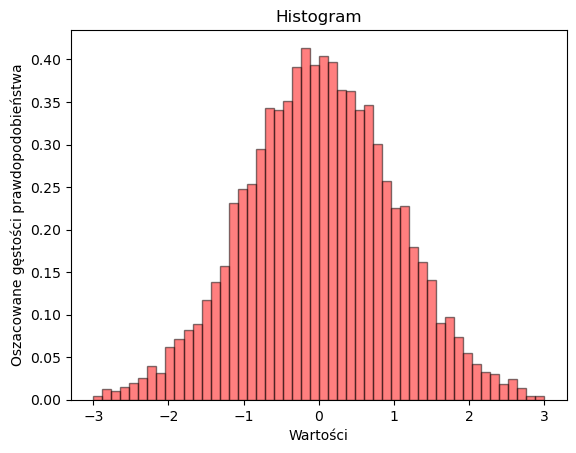

In [535]:
data = np.random.standard_normal(size=10000)

#tworzymy histogram za pomocą plt.hist
#argument density=True służy normalizacji wykresu
#warto poeksperymentować z argumentem bins
plt.hist(data, bins=50, density=True, alpha=0.5, color='r', edgecolor='black', range=(-3, 3), cumulative=False)

plt.title('Histogram')
plt.xlabel('Wartości')
plt.ylabel('Oszacowane gęstości prawdopodobieństwa')

#piszemy data;, aby nie wyświetlać naszej tablicy
data;

Jeśli chcemy porównać nasz znormalizowany histogram z teoretyczną funkcją gęstości naszej zmiennej, możemy nanieść na histogram ową funkcję w następujący sposób:

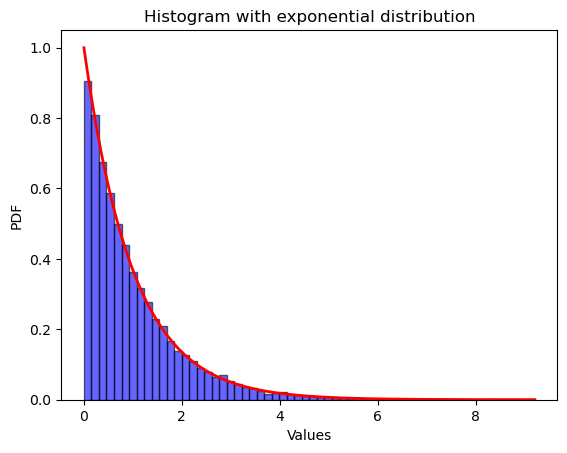

In [536]:
#funkcje gęstości bierzemy z biblioteki scipy.stats 
import scipy.stats as stats

data = np.random.exponential(1, size=10000)

x = np.linspace(np.min(data), np.max(data), 10000)
pdf_x = stats.expon.pdf(x, scale=1)

plt.hist(data, bins=60, density=True, alpha=0.6, color='b', edgecolor='black')
plt.title('Histogram with exponential distribution')
plt.xlabel('Values')
plt.ylabel('PDF')
plt.plot(x, pdf_x, color='r', lw=2)
#lw ustawia szerokość linii 

Możemy postąpić analogicznie przy szacowaniu __dystrybuanty__ (___cdf___) rozkładu danych:

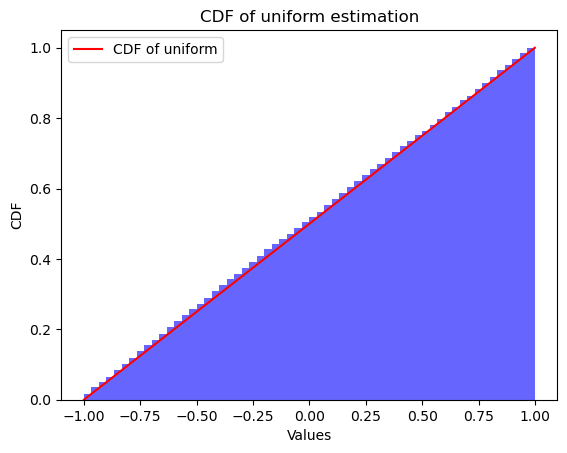

In [537]:
data = np.random.uniform(low=-1, high=1, size=10000)

x = np.linspace(np.min(data), np.max(data), 10000)
x_cdf = stats.uniform.cdf(x, loc=-1, scale=2)
#scale tutaj oznacza długość przedziału

fig, ax = plt.subplots()

ax.hist(data, bins=60, density=True, alpha=0.6, color='b', cumulative=True)
ax.plot(x, x_cdf, color='red', lw=1.5, label='CDF of uniform')
ax.set(xlabel='Values', ylabel='CDF', title='CDF of uniform estimation')
ax.legend()


Możemy też korzystać z pakietu scipy.stats, aby generować dane o danym rozkładzie, korzystając z metody rvs (również zwracana jest numpy.ndarray).

In [538]:
from scipy.stats import binom

data = binom.rvs(n=5, p=0.5, size=10)
print(type(data))
print(data)

<class 'numpy.ndarray'>
[3 2 4 0 3 2 1 1 3 3]


Oczywiście możemy porównywać histogramy wizualnie, stawiając je obok siebie w jednej figurze:

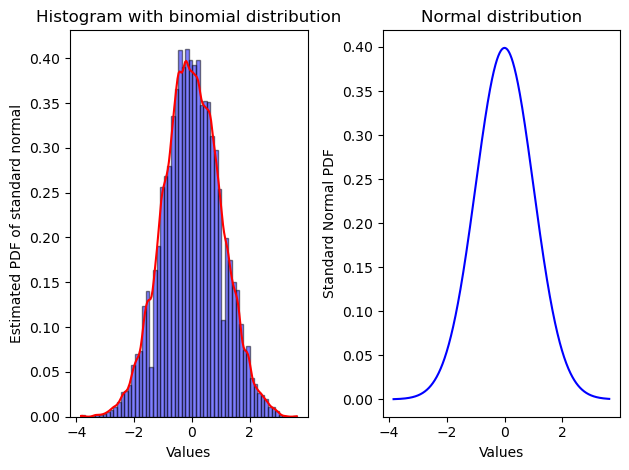

In [539]:
from scipy.stats import norm
from seaborn import kdeplot

np.random.seed(1)

data = np.random.binomial(n=1000, p=0.5, size=10000)
data = data - np.mean(data)
data = data / (np.var(data) ** 0.5)

fig, ax = plt.subplots(1, 2)

ax[0].hist(data, bins=60, density=True, alpha=0.5, color='b', edgecolor='black')
kdeplot(data, ax=ax[0], fill=False, color='r', clip=(min(data), max(data)), bw_adjust=0.5)
ax[0].set_title('Histogram with binomial distribution')
ax[0].set_xlabel('Values')
ax[0].set_ylabel('Estimated PDF of standard normal')

x = np.linspace(np.min(data), np.max(data), 1000)
pdf_x = norm.pdf(x)

ax[1].plot(x, pdf_x, color='b')
ax[1].set(xlabel='Values', ylabel='Standard Normal PDF', title='Normal distribution')

fig.tight_layout()
fig.savefig('comparison.png')



Mając pewne dane pochodzące z nieznanego rozkładu możemy użyć wykresu KDE (kernel density estimation), aby zwizualizować szacunkową gęstość tego rozkładu. Do celu potrzebujemy biblioteki `seaborn`.

Text(0.5, 1.0, 'Gaussian')

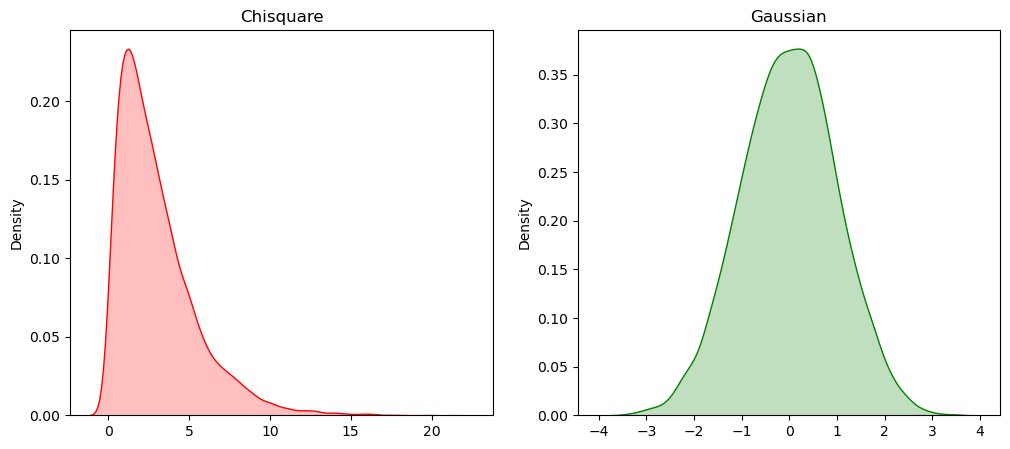

In [540]:
from seaborn import kdeplot as kde
from scipy import stats

data_chi = np.random.chisquare(3, 10000)
data_gaussian = stats.norm.rvs(scale=1, loc=0, size=10000)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
kde(data_chi, fill=True, color='red')
plt.title('Chisquare')

plt.subplot(1, 2, 2)
kde(data_gaussian, fill=True, color='green')
plt.title('Gaussian')



Do ważniejszych parametrów funkcji `seaborn.kdeplot` należy tzw. _bandwidth_, który kontroluje poziom wygładzenia estymacji wykresu funkcji gęstości. Jeśli jego wartość jest mała, nasz wykres będzie bardziej wrażliwy na drobne fluktuacje w danych (możliwy _overfitting_). Wraz ze zwiększaniem wartości _bandwidth_ funkcja KDE staje się bardziej wygładzona, skutkując w utracie drobnych szczegółów w danych, dając w zamian bardziej ogólny obraz dystrybucji. (możliwy _underfitting_). Warto pobróbować kilka wartości, aby znaleźć złoty środek.

(0.0, 10.0)

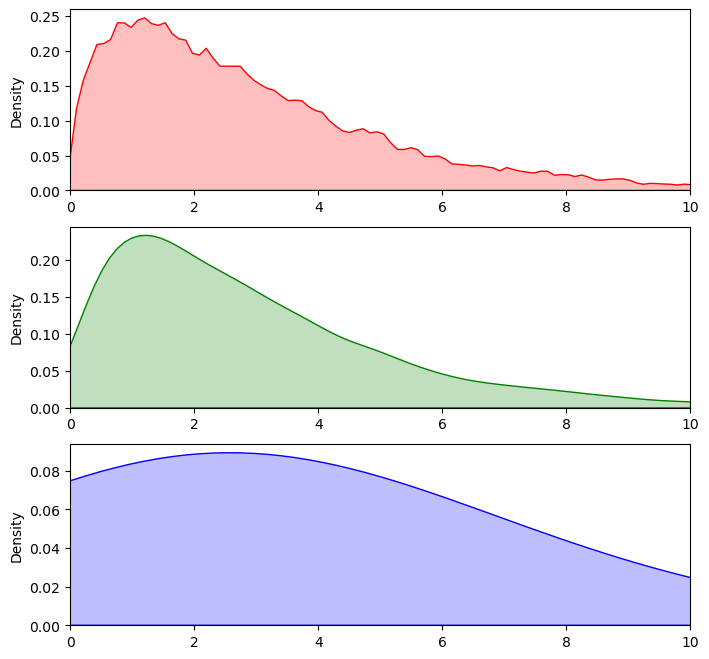

In [541]:
plt.figure(figsize=(8, 8))

plt.subplot(3, 1, 1)
kde(data_chi, fill=True, color='red', bw_adjust=0.2)
plt.xlim(0, 10)

plt.subplot(3, 1, 2)
kde(data_chi, fill=True, color='green', bw_adjust=1.0)
plt.xlim(0, 10)

plt.subplot(3, 1, 3)
kde(data_chi, fill=True, color='blue', bw_adjust=10)
plt.xlim(0, 10)



Inne ważne parametry `seaborn.kdeplot` obejmują:
* __fill__ (=shade)
False/True; aktywuje wypełnienie pod krzywą
* __clip__
odpowiednik ___range___ z `matplotlib.pyplot.hist`
* __cumulative__
* __lw__
określa szerokość linii wykresu.

___Seaborn___ umożliwia również nakładać wykres KDE na histogram, wykorzystując ___seaborn.histplot___ z parametrem `kde=True`

Jeśli chcemy oszacować dystrybuantę bądź gęstość naszego rozkładu, nie musimy ograniczać się do wizualizacji. Moduł `scipy.stats` zapewnia funkcję `gaussian_kde`, która przyjmuje dane i zwraca obiekt będący funkcją (szacunkową funkcją gęstości rozkładu tych danych):

<Axes: ylabel='Density'>

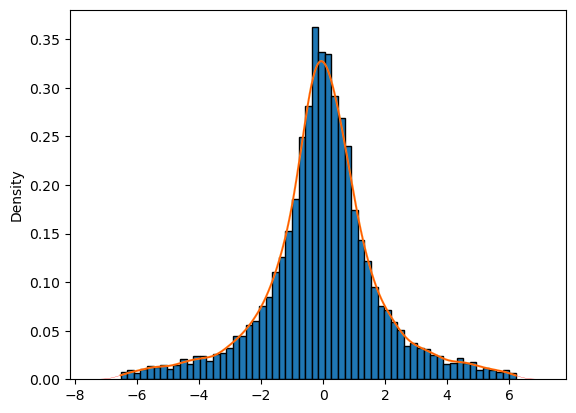

In [542]:
from scipy.stats import gaussian_kde

data = np.random.standard_cauchy(size=10000)

#ze względu na specyfikę rozkładu Cauchyego, dobrym pomysłem 
#będzie pozbycie się tzw. outliers

lower_bound = np.percentile(data, 5)
upper_bound = np.percentile(data, 95)


def outlier_filter(x):
    return (x >= lower_bound) and (x <= upper_bound)


outlier_filter = np.vectorize(outlier_filter)
data_filter = outlier_filter(data)
data = data[data_filter]

kde = gaussian_kde(data)
kde_vec = np.vectorize(kde)

x = np.linspace(np.min(data), np.max(data), 10000)
pdf = kde_vec(x)

plt.hist(data, bins=60, density=True, edgecolor='black')
plt.plot(x, pdf)

###dla porownania naniesmy jeszcze wykres szacunkowego pdf uzyskanego metodą kde:
sns.kdeplot(data, fill=False, color='red', lw=0.2)
###widać, że wykresy się pokrywają



W podobny sposób możemy szacować dystrybuantę. Biblioteka `statsmodels` udostępnia klasę `ECDF`, która szybko oblicza empiryczną dystrybuantę. Pouczającym zadaniem jest napisanie samemu takiej funkcji.

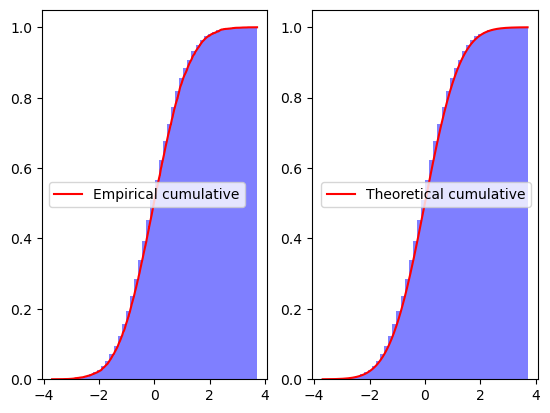

In [543]:
from scipy.stats import norm


def cdf_estimation(x, sorted_data: np.ndarray) -> float:
    result = np.searchsorted(sorted_data, x, side='right') / len(sorted_data)
    return result


data = np.random.standard_normal(size=10000)
sorted_data = np.sort(data)

x = np.linspace(min(data), max(data), 10000)
norm_ecdf = cdf_estimation(x, sorted_data)
norm_cdf = norm.cdf(x)

fig, ax = plt.subplots(nrows=1, ncols=2)
ax[0].plot(x, norm_ecdf, label="Empirical cumulative", color='red')
ax[0].hist(data, bins=50, cumulative=True, density=True, alpha=0.5, color='blue')
ax[0].legend()

ax[1].plot(x, norm_cdf, label="Theoretical cumulative", color='red')
ax[1].hist(data, bins=50, cumulative=True, density=True, alpha=0.5, color='blue')
ax[1].legend()

data;


### Zad 6 (2 punkty)
Wygeneruj dwie próbki danych z rozkładu normalnego: 1000 obserwacji z $\mathcal{N}(2, 0.25)$ oraz 1000 obserwacji z $\mathcal{N}(5, 1)$. Połącz je w jedną, jednowymiarową tablicę. Narysuj na jednym wykresie znormalizowany histogram dla połączonych danych (korzystając z 30 przedziałów) oraz nałóż na niego estymator jądrowy gęstości (KDE). Sprawdź, jak zmienia się wykres gęstości, modyfikując parametr wygładzania KDE na bardzo mały (np. 0.1) oraz bardzo duży (np. 3.0). Skomentuj, w jaki sposób KDE radzi sobie z wygładzaniem i czy poprawnie identyfikuje dwie mody rozkładu.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

rng = np.random.default_rng(2026)
x1 = rng.normal(loc=2.0, scale=0.5, size=1000)
x2 = rng.normal(loc=5.0, scale=1.0, size=1000)
data = np.concatenate([x1, x2])

plt.figure(figsize=(10, 6))
plt.hist(data, bins=30, density=True, alpha=0.35, edgecolor='black', label='Histogram')
sns.kdeplot(data, bw_adjust=0.1, label='KDE bw=0.1', color='red')
sns.kdeplot(data, bw_adjust=1.0, label='KDE bw=1.0', color='blue')
sns.kdeplot(data, bw_adjust=3.0, label='KDE bw=3.0', color='green')
plt.title('Zad 6: mieszanina dwoch rozkladow normalnych')
plt.xlabel('x')
plt.ylabel('gestosc')
plt.legend()
plt.show()

print('bw=0.1: bardzo poszarpany wykres (duza wrazliwosc na szum).')
print('bw=3.0: silne wygladzenie, mody moga sie zlewac.')
print('bw blisko 1.0 zwykle najlepiej ujawnia dwie mody tej mieszaniny.')

### Zad 7 (2 punkty)
Zastosuj metodę Monte Carlo do oszacowania wartości liczby $\pi$. Wygeneruj 10000 losowych punktów o współrzędnych $(x, y)$ z rozkładu jednostajnego na kwadracie $[-1, 1] \times [-1, 1]$. Zlicz, ile punktów wpadło do koła o promieniu 1 (tj. spełniło warunek $x^2 + y^2 \le 1$), a następnie na tej podstawie oblicz przybliżenie liczby $\pi$. Narysuj wykres punktowy wszystkich losowań, zaznaczając innym kolorem punkty wewnątrz koła, a innym te lądujące na zewnątrz.

Oszacowanie pi = 3.165200


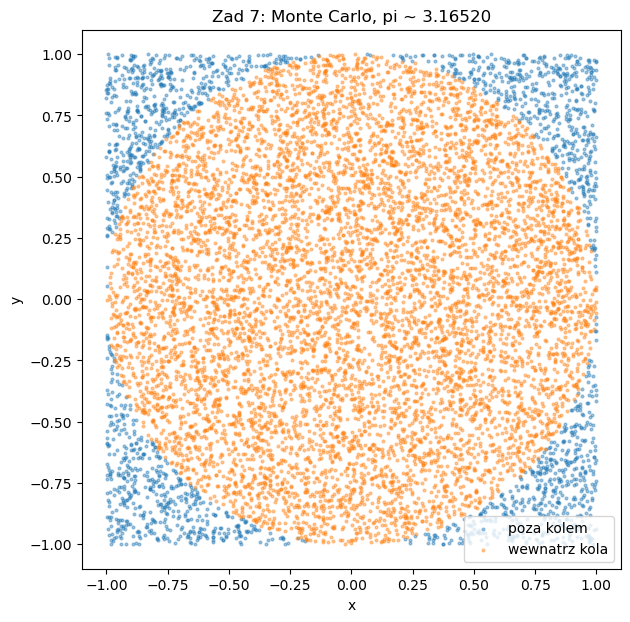

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(2137)
n = 10000
x = rng.uniform(-1, 1, size=n)
y = rng.uniform(-1, 1, size=n)

inside = x**2 + y**2 <= 1
pi_hat = 4 * inside.mean()
print(f"Oszacowanie pi = {pi_hat:.6f}")

plt.figure(figsize=(7, 7))
plt.scatter(x[~inside], y[~inside], s=4, alpha=0.4, label='poza kolem')
plt.scatter(x[inside], y[inside], s=4, alpha=0.4, label='wewnatrz kola')
plt.gca().set_aspect('equal', adjustable='box')
plt.title(f'Zad 7: Monte Carlo, pi ~ {pi_hat:.5f}')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

### Zad 8 (2 punkty)
Wygeneruj próbkę 500 punktów z rozkładu wykładniczego o parametrze $\lambda = 1$. Narysuj trzy oddzielne znormalizowane histogramy dla tych samych danych, stosując odpowiednio 5, 50 oraz 500 przedziałów (binów). Dodaj do każdego wykresu krzywą gęstości KDE. Opisz zjawiska zbyt małej liczby przedziałów (under-binning) oraz zbyt dużej liczby przedziałów (over-binning) i skomentuj, dlaczego metoda KDE jest często lepszym narzędziem do wizualizacji rzeczywistego kształtu rozkładu.

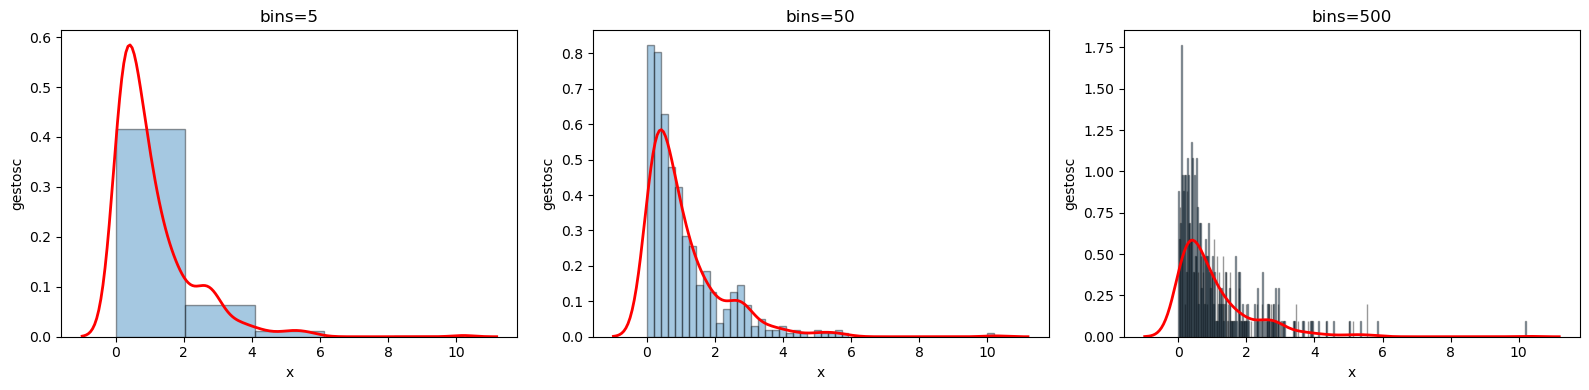

5 binow: under-binning, duza utrata szczegolow.
500 binow: over-binning, histogram jest niestabilny i zaszumiony.
KDE zwykle lepiej pokazuje gladki ksztalt rozkladu.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

rng = np.random.default_rng(2026)
data = rng.exponential(scale=1.0, size=500)
bins_list = [5, 50, 500]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, b in zip(axes, bins_list):
    ax.hist(data, bins=b, density=True, alpha=0.4, edgecolor='black')
    sns.kdeplot(data, ax=ax, color='red', lw=2)
    ax.set_title(f'bins={b}')
    ax.set_xlabel('x')
    ax.set_ylabel('gestosc')
plt.tight_layout()
plt.show()

print('5 binow: under-binning, duza utrata szczegolow.')
print('500 binow: over-binning, histogram jest niestabilny i zaszumiony.')
print('KDE zwykle lepiej pokazuje gladki ksztalt rozkladu.')

### Zad 9 (2 punkty)
Wygeneruj 3000 punktów z dwuwymiarowego rozkładu normalnego o wektorze średnich $\mu = [0, 0]$ i macierzy kowariancji $\Sigma = [[1, 0.7], [0.7, 1]]$. Aby uniknąć problemu zlewających się punktów na standardowym wykresie punktowym, stwórz dwa wykresy obok siebie: dwuwymiarowy histogram heksagonalny (np. korzystając z funkcji `hexbin`) oraz wykres konturowy gęstości 2D KDE z wypełnieniem. Zaobserwuj i opisz krótko, jak kształt izolinii obrazuje korelację między zmiennymi.

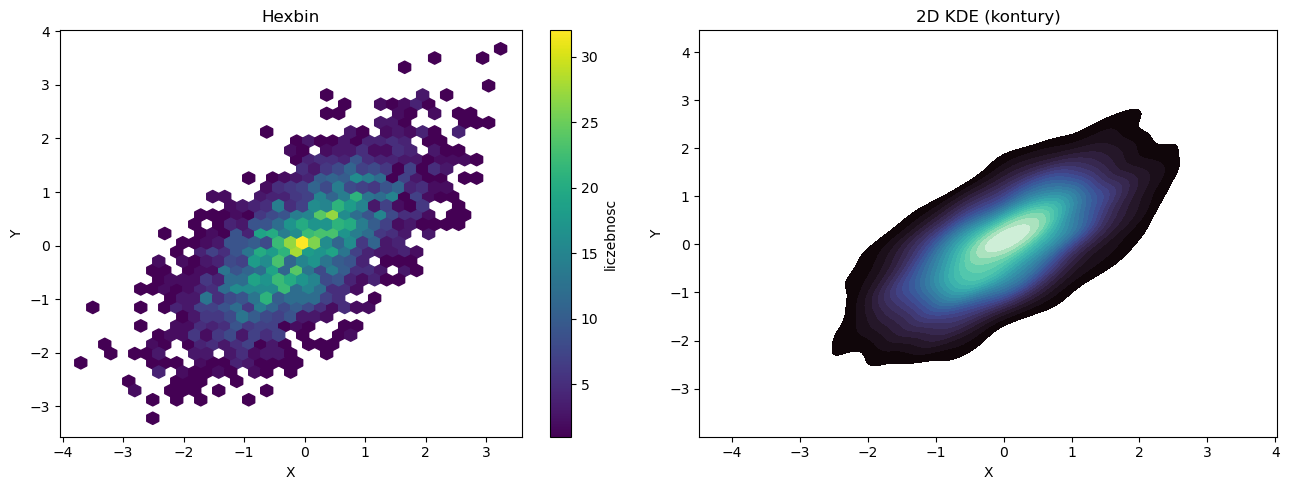

Eliptyczne, ukosne kontury wskazuja dodatnia korelacje miedzy zmiennymi.


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

rng = np.random.default_rng(2026)
mu = np.array([0.0, 0.0])
Sigma = np.array([[1.0, 0.7], [0.7, 1.0]])
data = rng.multivariate_normal(mu, Sigma, size=3000)
x, y = data[:, 0], data[:, 1]

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
hb = ax[0].hexbin(x, y, gridsize=35, cmap='viridis', mincnt=1)
ax[0].set_title('Hexbin')
ax[0].set_xlabel('X')
ax[0].set_ylabel('Y')
fig.colorbar(hb, ax=ax[0], label='liczebnosc')

sns.kdeplot(x=x, y=y, fill=True, levels=25, cmap='mako', ax=ax[1])
ax[1].set_title('2D KDE (kontury)')
ax[1].set_xlabel('X')
ax[1].set_ylabel('Y')

plt.tight_layout()
plt.show()

print('Eliptyczne, ukosne kontury wskazuja dodatnia korelacje miedzy zmiennymi.')

### Zad 10 (2 punkty)
Użyj metody Monte Carlo do całkowania numerycznego. Wyznacz pole pod krzywą funkcji $f(x) = \sin(x)$ na przedziale $[0, \pi]$. W tym celu wylosuj 5000 punktów $(x, y)$, gdzie $x \sim \text{Unif}(0, \pi)$, a $y \sim \text{Unif}(0, 1)$. Zlicz punkty, dla których $y < \sin(x)$, i na tej podstawie oszacuj pole, mnożąc pole całego obszaru losowania przez ułamek punktów "pod" krzywą. Narysuj wykres funkcji $\sin(x)$ na podanym przedziale oraz nanieś na niego wszystkie wylosowane punkty, zaznaczając różnymi kolorami te znajdujące się pod i nad krzywą.

Oszacowane pole pod sin(x) na [0, pi] = 1.998681
Dokladna wartosc = 2


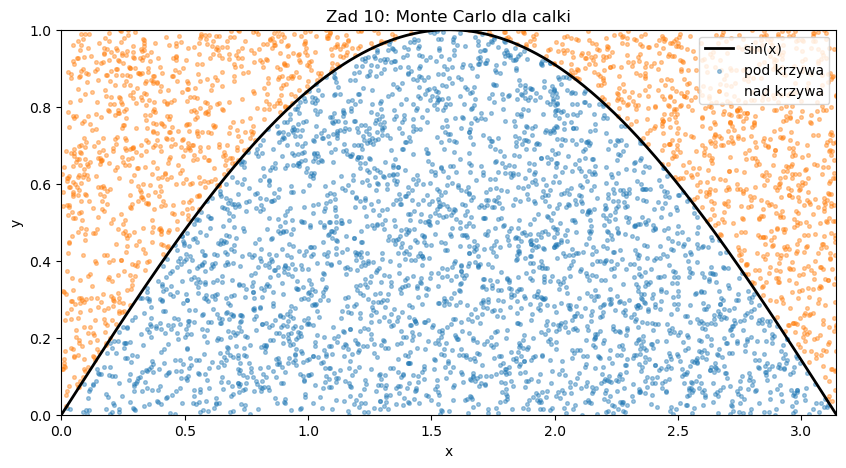

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(2137)
n = 5000
x = rng.uniform(0, np.pi, size=n)
y = rng.uniform(0, 1, size=n)
fx = np.sin(x)
under = y < fx

area_hat = np.pi * under.mean()
print(f"Oszacowane pole pod sin(x) na [0, pi] = {area_hat:.6f}")
print("Dokladna wartosc = 2")

xx = np.linspace(0, np.pi, 500)
plt.figure(figsize=(10, 5))
plt.plot(xx, np.sin(xx), color='black', lw=2, label='sin(x)')
plt.scatter(x[under], y[under], s=7, alpha=0.4, label='pod krzywa')
plt.scatter(x[~under], y[~under], s=7, alpha=0.4, label='nad krzywa')
plt.xlim(0, np.pi)
plt.ylim(0, 1)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Zad 10: Monte Carlo dla calki')
plt.legend()
plt.show()